In [1]:
import pandas as pd
import numpy as np
import os

processed_path = os.path.join("..", "Data", "Processed")

customer_segments = pd.read_csv(os.path.join(processed_path, "customer_segments.csv"))
elasticity_df = pd.read_csv(os.path.join(processed_path, "elasticity_by_segment.csv"))

transactions = pd.read_csv(os.path.join(processed_path, "transactions_clean.csv"))
transactions['InvoiceDate'] = pd.to_datetime(transactions['InvoiceDate'])

customer_segments.shape, elasticity_df.shape

((5878, 9), (4, 5))

In [2]:
segment_summary = customer_segments.groupby('Segment').agg(
    Num_Customers=('Customer ID', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Avg_Predicted_CLV=('predicted_clv', 'mean'),
    Churn_Rate=('Churned', 'mean')
).round(2)

segment_summary = segment_summary.merge(
    elasticity_df.set_index('Segment')[['elasticity', 'p_value']],
    left_index=True, right_index=True
)

segment_summary = segment_summary.sort_values('Avg_Predicted_CLV', ascending=False)
segment_summary

,Num_Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Predicted_CLV,Churn_Rate,elasticity,p_value
Segment,,,,,,,,
Champions,1188,27.43,19.34,11014.37,5393.00,0.06,-1.868746,0.002785
New/Occasional,1251,28.44,3.04,865.11,1030.74,0.03,-2.366706,0.003173
At-Risk,1465,227.87,5.10,2002.10,826.58,0.82,-0.438220,0.512469
Lost/Inactive,1974,395.86,1.38,325.75,92.87,0.95,1.945054,0.000230


In [3]:
recommendations = {
    'Champions': 'Protect & reward loyalty; avoid discounting (elastic even for loyal buyers)',
    'At-Risk': 'Priority retention target; use personalized win-back, not price cuts (elasticity unproven)',
    'New/Occasional': 'Use targeted promos; most price-responsive segment with low churn risk',
    'Lost/Inactive': 'Deprioritize; low-cost win-back only, poor ROI on retention spend'
}

segment_summary['Recommended_Action'] = segment_summary.index.map(recommendations)
segment_summary

segment_summary.to_csv(os.path.join(processed_path, "final_segment_summary.csv"))

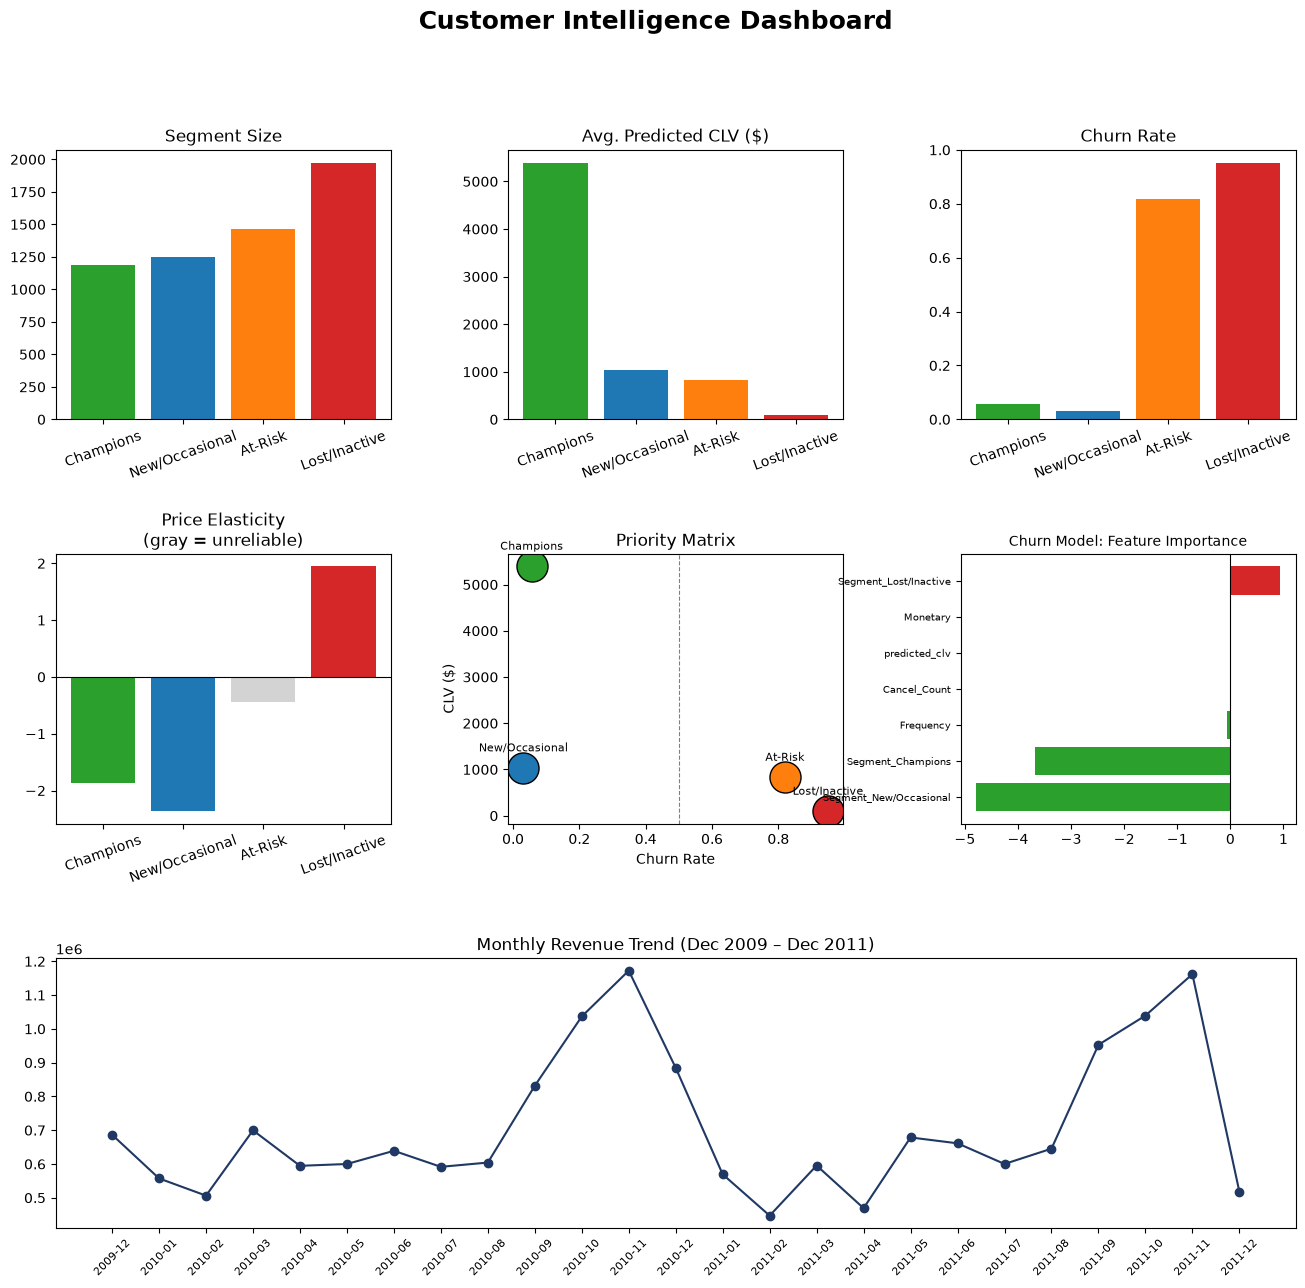

In [4]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LogisticRegression

segment_order = ['Champions', 'New/Occasional', 'At-Risk', 'Lost/Inactive']
colors = {'Champions': '#2ca02c', 'New/Occasional': '#1f77b4', 'At-Risk': '#ff7f0e', 'Lost/Inactive': '#d62728'}
bar_colors = [colors[s] for s in segment_order]

# Quick refit of churn model for the feature importance panel
model_data_encoded = pd.get_dummies(customer_segments, columns=['Segment'], drop_first=True)
model_data_encoded['predicted_clv'] = model_data_encoded['predicted_clv'].fillna(0)
feature_cols = ['Frequency', 'Monetary', 'Cancel_Count', 'predicted_clv'] + \
                [c for c in model_data_encoded.columns if c.startswith('Segment_')]
X_full = model_data_encoded[feature_cols]
y_full = model_data_encoded['Churned']
logreg_final = LogisticRegression(random_state=42, max_iter=1000).fit(X_full, y_full)
importance_plot = pd.Series(logreg_final.coef_[0], index=X_full.columns).sort_values()

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.35)
fig.suptitle('Customer Intelligence Dashboard', fontsize=18, fontweight='bold', y=0.98)

# 1. Segment size
ax1 = fig.add_subplot(gs[0,0])
sizes = customer_segments['Segment'].value_counts().reindex(segment_order)
ax1.bar(segment_order, sizes.values, color=bar_colors)
ax1.set_title('Segment Size'); ax1.tick_params(axis='x', rotation=20)

# 2. CLV
ax2 = fig.add_subplot(gs[0,1])
clv = customer_segments.groupby('Segment')['predicted_clv'].mean().reindex(segment_order)
ax2.bar(segment_order, clv.values, color=bar_colors)
ax2.set_title('Avg. Predicted CLV ($)'); ax2.tick_params(axis='x', rotation=20)

# 3. Churn rate
ax3 = fig.add_subplot(gs[0,2])
churn = customer_segments.groupby('Segment')['Churned'].mean().reindex(segment_order)
ax3.bar(segment_order, churn.values, color=bar_colors)
ax3.set_title('Churn Rate'); ax3.set_ylim(0,1); ax3.tick_params(axis='x', rotation=20)

# 4. Elasticity
ax4 = fig.add_subplot(gs[1,0])
elast_lookup = elasticity_df.set_index('Segment')
elast_colors = [bar_colors[i] if elast_lookup.loc[s,'p_value']<0.05 else 'lightgray' for i,s in enumerate(segment_order)]
ax4.bar(segment_order, elast_lookup.reindex(segment_order)['elasticity'].values, color=elast_colors)
ax4.axhline(0, color='black', linewidth=0.8)
ax4.set_title('Price Elasticity\n(gray = unreliable)'); ax4.tick_params(axis='x', rotation=20)

# 5. Priority matrix
ax5 = fig.add_subplot(gs[1,1])
for seg in segment_order:
    row = customer_segments[customer_segments['Segment']==seg]
    ax5.scatter(row['Churned'].mean(), row['predicted_clv'].mean(), s=500, color=colors[seg], edgecolor='black')
    ax5.annotate(seg, (row['Churned'].mean(), row['predicted_clv'].mean()), textcoords="offset points", xytext=(0,12), ha='center', fontsize=8)
ax5.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax5.set_xlabel('Churn Rate'); ax5.set_ylabel('CLV ($)'); ax5.set_title('Priority Matrix')

# 6. Feature importance
ax6 = fig.add_subplot(gs[1,2])
imp_colors = ['#d62728' if v>0 else '#2ca02c' for v in importance_plot.values]
ax6.barh(importance_plot.index, importance_plot.values, color=imp_colors)
ax6.axvline(0, color='black', linewidth=0.8)
ax6.set_title('Churn Model: Feature Importance', fontsize=10)
ax6.tick_params(axis='y', labelsize=7)

# 7. Revenue trend (full width bottom row)
ax7 = fig.add_subplot(gs[2,:])
transactions['Month'] = transactions['InvoiceDate'].dt.to_period('M')
monthly_revenue = transactions.groupby('Month')['TotalPrice'].sum()
ax7.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', color='#1f3864')
ax7.set_title('Monthly Revenue Trend (Dec 2009 – Dec 2011)')
ax7.tick_params(axis='x', rotation=45, labelsize=8)

plt.savefig(os.path.join(processed_path, '..', 'dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()